In [1]:
from statsmodels.stats.power import TTestIndPower
analysis = TTestIndPower()

In [2]:
n_samples = {1 : {"n_ctrl": 2, "n_pd": 4},
             4: {"n_ctrl": 22, "n_pd": 28},
             5: {"n_ctrl": 10, "n_pd": 14},
             "Integrated" : {"n_ctrl": 57, "n_pd": 46}}

In [3]:
for dataset in n_samples:
    n_ctrl = n_samples[dataset]["n_ctrl"]
    n_pd = n_samples[dataset]["n_pd"]
    cohen = analysis.solve_power(
        power = 0.8,
        effect_size= None,
        nobs1=n_ctrl,
        ratio=n_pd/n_ctrl,
        alpha=0.05,
        alternative="two-sided"
    )
    print(f"{dataset}: Cohen's d = {cohen:.2f}")

1: Cohen's d = 3.26
4: Cohen's d = 0.81
5: Cohen's d = 1.21
Integrated: Cohen's d = 0.56


In [4]:
for dataset in n_samples:
    n_ctrl = n_samples[dataset]["n_ctrl"]
    n_pd = n_samples[dataset]["n_pd"]
    cohen = analysis.solve_power(
        power = None,
        effect_size= 0.5,
        nobs1=n_ctrl,
        ratio=n_pd/n_ctrl,
        alpha=0.05,
        alternative="two-sided"
    )
    print(f"{dataset}: Power = {cohen:.2f}")

1: Power = 0.07
4: Power = 0.41
5: Power = 0.21
Integrated: Power = 0.70


1: Cohen's d = 3.26, Total N = 6
4: Cohen's d = 0.81, Total N = 50
5: Cohen's d = 1.21, Total N = 24
Integrated: Cohen's d = 0.56, Total N = 103


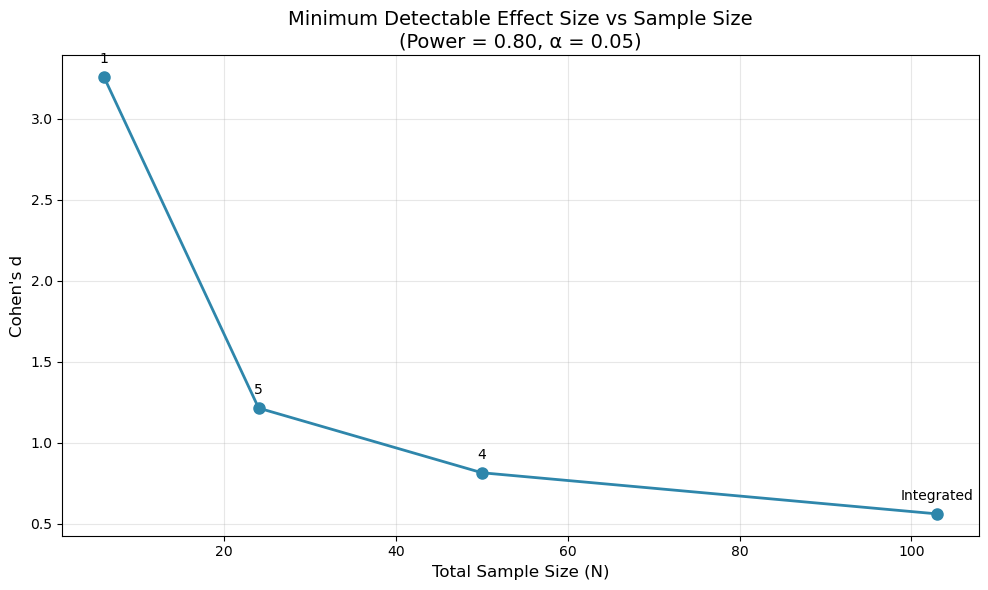

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate Cohen's d for each dataset
datasets = []
cohens_d = []

for dataset in n_samples:
    n_ctrl = n_samples[dataset]["n_ctrl"]
    n_pd = n_samples[dataset]["n_pd"]
    total_n = n_ctrl + n_pd
    
    cohen = analysis.solve_power(
        power=0.8,
        effect_size=None,
        nobs1=n_ctrl,
        ratio=n_pd/n_ctrl,
        alpha=0.05,
        alternative="two-sided"
    )
    
    datasets.append(str(dataset))
    cohens_d.append(cohen)
    print(f"{dataset}: Cohen's d = {cohen:.2f}, Total N = {total_n}")

# Create line plot
fig, ax = plt.subplots(figsize=(10, 6))

# Get total sample sizes for x-axis
x_values = [n_samples[d]["n_ctrl"] + n_samples[d]["n_pd"] for d in n_samples.keys()]
x_labels = list(n_samples.keys())

# Sort by total sample size for better visualization
sorted_pairs = sorted(zip(x_values, cohens_d, x_labels))
x_values_sorted = [x[0] for x in sorted_pairs]
cohens_d_sorted = [x[1] for x in sorted_pairs]
x_labels_sorted = [x[2] for x in sorted_pairs]

ax.plot(x_values_sorted, cohens_d_sorted, marker='o', linewidth=2, markersize=8, color='#2E86AB')
ax.set_xlabel("Total Sample Size (N)", fontsize=12)
ax.set_ylabel("Cohen's d", fontsize=12)
ax.set_title("Minimum Detectable Effect Size vs Sample Size\n(Power = 0.80, α = 0.05)", fontsize=14)
ax.grid(True, alpha=0.3)

# Add dataset labels to points
for i, label in enumerate(x_labels_sorted):
    ax.annotate(label, (x_values_sorted[i], cohens_d_sorted[i]), 
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=10)

plt.tight_layout()
plt.show()